# Avaliando Redes Neurais - 04/04/2026 

In [107]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
from pathlib import Path

In [108]:
def get_training_table(file: str) -> pd.DataFrame:
    errors = []
    with open(file) as fp:
        for line in fp:
            if re.match("^ *[0-9].*<$", line):
                errors.append([float(a) for a in line.split()[1:-1]])

    errors = np.array(errors)
    df = pd.DataFrame(data=errors, columns=["MAE_train", "RMSE_train", "MAE_test", "RMSE_test"])
    return df

In [109]:
fpath = r"/home/joaovc/aenet-2.0.3/LDA_MLIP-2026-03-25/02-train/NN-10x10/train_10.out"
df = get_training_table(fpath)
df

,MAE_train,RMSE_train,MAE_test,RMSE_test
0,2.761395,3.202409,2.776898,3.222903
1,2.761395,3.202409,2.776898,3.222903
2,3.584158,3.933779,3.575455,3.929939
3,1.696710,1.902107,1.729555,1.926575
4,1.239200,1.362149,1.264984,1.382466
...,...,...,...,...
7996,0.001072,0.001724,0.001422,0.003389
7997,0.001072,0.001724,0.001421,0.003390
7998,0.001072,0.001723,0.001422,0.003391
7999,0.001072,0.001723,0.001422,0.003392


In [110]:
print(f"Melhor ajuste da energia em eV: {df["RMSE_test"].min():3e} meV", )
print(f"Melhor época de treinamento: {df["RMSE_test"].idxmin()}") 

Melhor ajuste da energia em eV: 3.383935e-03 meV
Melhor época de treinamento: 7985


In [111]:
def plot_training_table(df: pd.DataFrame) -> None:
    epochs = np.arange(1, len(df) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, df['RMSE_train'], label='train')
    axes[0].plot(epochs, df['RMSE_test'], label='test')

    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("E")
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # =========================
    # Painel 2: escala log
    # =========================
    axes[1].plot(epochs, df['RMSE_train'], label='train')
    axes[1].plot(epochs, df['RMSE_test'], label='test')

    axes[1].set_xscale('log')
    axes[1].set_yscale('log')

    axes[1].set_xlabel("epoch")
    axes[1].set_title("Log-Scale")
    axes[1].legend()
    #axes[1].grid(FAL, which='both', linestyle='--', alpha=0.5)

    # --- layout e salvamento ---
    plt.tight_layout()
    plt.savefig("training_error.png", dpi=300, bbox_inches="tight")
    plt.show()

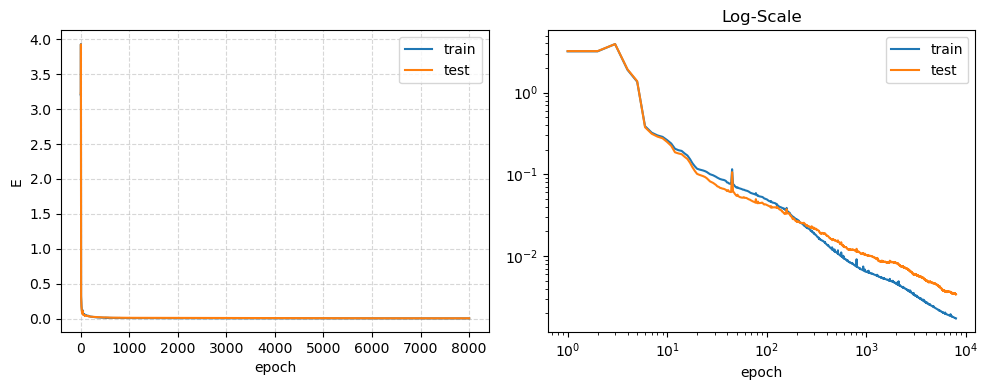

In [112]:
plot_training_table(df)

<Axes: >

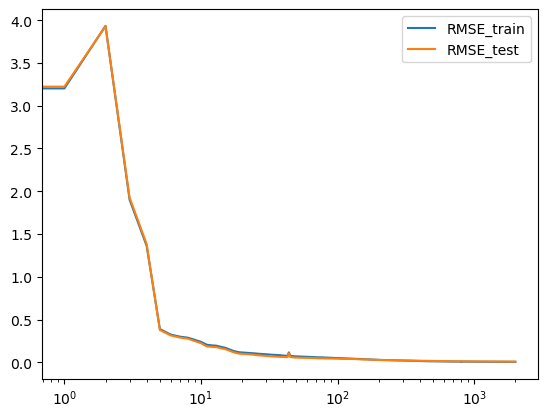

In [114]:
max_epoch = 2_000
df[["RMSE_train", "RMSE_test"]][:max_epoch].plot(logx=True)

In [17]:
df["RMSE_test"].min(), df["RMSE_test"].idxmin()

(0.003383935, 7985)

In [31]:
df.loc[df["RMSE_test"].idxmin()] * 1_000

MAE_train     1.073681
RMSE_train    1.725279
MAE_test      1.418802
RMSE_test     3.383935
Name: 7985, dtype: float64

---


# Figuras de Paridade

In [21]:
def get_predict_energies(predict_out: str) -> pd.DataFrame:
    """
    Lê o arquivo predict.out do ænet e extrai:
      - nome do arquivo XSF
      - energia total (eV)
    Retorna um DataFrame com colunas:
      ['filename', 'total_energy_ann (eV)']
    """
    text = Path(predict_out).read_text()
    
    # Captura: nome do arquivo .xsf, energia total
    pattern = (
        r"File name\s*:\s*(\S+\.xsf).*?"
        r"Total energy\s*:\s*([-\d.]+).*?"
        # r"RMS force\s*:\s*([-\d.]+)"
    )
    
    matches = re.findall(pattern, text, re.S)
    
    df = pd.DataFrame(matches, columns=['filename', 'E_ANN (eV)'])
    df['E_ANN (eV)'] = df['E_ANN (eV)'].astype(float)
    # df['rms_force (eV/Å)'] = df['rms_force (eV/Å)'].astype(float)
    
    # Remove caminhos e deixa só o nome do arquivo (ex: structure0003.xsf)
    df['filename'] = df['filename'].apply(lambda x: Path(x).name)
    
    return df

In [30]:
def get_dft_energies(xsfs_dir: str) -> pd.DataFrame:
    """
    Lê arquivos .xsf e extrai:
      - nome do arquivo
      - energia total (E_DFT)
      - número de átomos (N_atoms, via linha PRIMCOORD)
    """
    pattern_energy = re.compile(r"#\s*total energy\s*=\s*([-+]?\d*\.\d+|\d+)\s*eV")
    pattern_natoms = re.compile(r"PRIMCOORD\s*\n\s*(\d+)\s+\d+")

    data = []
    for file in sorted(Path(xsfs_dir).glob("*.xsf")):
        text = file.read_text()

        match_e = pattern_energy.search(text)
        match_n = pattern_natoms.search(text)

        if match_e and match_n:
            energy = float(match_e.group(1))
            natoms = int(match_n.group(1))
            data.append((file.name, energy, natoms))

    return pd.DataFrame(data, columns=["filename", "E_DFT (eV)", "N_atoms"])

In [29]:
predict_energies_df = get_predict_energies("../02-train/NN-10x10/03-predict/predict.out")
predict_energies_df

,filename,E_ANN (eV)
0,LDA-0001.xsf,-12263.616293
1,LDA-0002.xsf,-24527.232547
2,LDA-0003.xsf,-36790.848840
3,LDA-0004.xsf,-24527.232580
4,LDA-0006.xsf,-73581.697916
...,...,...
1245,LDA-6271.xsf,-49069.667298
1246,LDA-6283.xsf,-24534.861036
1247,LDA-6287.xsf,-98138.076402
1248,LDA-6289.xsf,-73603.785942


In [34]:
! ls ../

01-generate  02-train  03-predict  LDA_test_set  LDA_training_set  Notebooks


In [35]:
energies_dft = get_dft_energies("../LDA_test_set/")
energies_dft

,filename,E_DFT (eV),N_atoms
0,LDA-0001.xsf,-12263.612645,4
1,LDA-0002.xsf,-24527.225291,8
2,LDA-0003.xsf,-36790.835241,12
3,LDA-0004.xsf,-24527.225291,8
4,LDA-0006.xsf,-73581.670483,24
...,...,...,...
1245,LDA-6271.xsf,-49069.742855,16
1246,LDA-6283.xsf,-24534.873116,8
1247,LDA-6287.xsf,-98138.030809,32
1248,LDA-6289.xsf,-73603.688869,24


In [36]:
# Merge the two dataframes 

df = pd.concat(
    [predict_energies_df, energies_dft.drop('filename', axis=1),],
    axis=1,   
    
)
df

,filename,E_ANN (eV),E_DFT (eV),N_atoms
0,LDA-0001.xsf,-12263.616293,-12263.612645,4
1,LDA-0002.xsf,-24527.232547,-24527.225291,8
2,LDA-0003.xsf,-36790.848840,-36790.835241,12
3,LDA-0004.xsf,-24527.232580,-24527.225291,8
4,LDA-0006.xsf,-73581.697916,-73581.670483,24
...,...,...,...,...
1245,LDA-6271.xsf,-49069.667298,-49069.742855,16
1246,LDA-6283.xsf,-24534.861036,-24534.873116,8
1247,LDA-6287.xsf,-98138.076402,-98138.030809,32
1248,LDA-6289.xsf,-73603.785942,-73603.688869,24


In [38]:
df['E_ANN (eV)/atom'] = df['E_ANN (eV)'] / df['N_atoms']
df['E_DFT (eV)/atom'] = df['E_DFT (eV)'] / df['N_atoms']
df['Delta_E/Atom'] = abs(df['E_DFT (eV)/atom'] - df['E_ANN (eV)/atom'])


display(df['Delta_E/Atom'].describe())

count    1250.000000
mean        0.001413
std         0.002373
min         0.000002
25%         0.000288
50%         0.000654
75%         0.001375
max         0.030018
Name: Delta_E/Atom, dtype: float64

In [39]:
RMSE = np.sqrt( (df['Delta_E/Atom']**2).sum() / df.shape[0])
RMSE_meV = RMSE*1_000


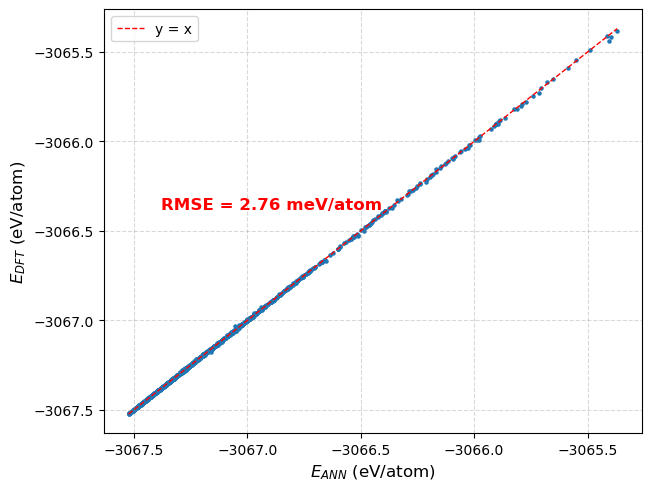

In [82]:

fig, ax = plt.subplots(layout="constrained")
ax.scatter(
    x=df['E_ANN (eV)/atom'],
    y=df['E_DFT (eV)/atom'],
    s=5
)

lims = [
    min(df['E_ANN (eV)/atom'].min(), df['E_DFT (eV)/atom'].min()),
    max(df['E_ANN (eV)/atom'].max(), df['E_DFT (eV)/atom'].max())
]
ax.set_xlabel("$E_{ANN}$ (eV/atom)", fontsize=12);
ax.set_ylabel("$E_{DFT}$ (eV/atom)", fontsize=12);

# Linha de referência y = x
ax.plot(lims, lims, 'r--', lw=1, label='y = x')

x_text = ax.get_xlim()[0] + .25
y_text = ax.get_ylim()[0] + 1.25
font = dict(family='sans-serif', color='red', weight='bold', size=12)
ax.text(y=y_text, x=x_text, s=f"RMSE = {RMSE_meV:.2f} meV/atom", fontdict=font)

ax.grid(alpha=0.3, ls="--", color='gray')
ax.legend()
plt.show()

# Evaluation of Forces

In [ ]:
def read_predict_forces(filepath: str) -> pd.DataFrame:
    """Lê predict.out do ænet e retorna DataFrame com nome da estrutura e forças (Fx, Fy, Fz)."""
    data = []
    with open(filepath, "r") as f:
        lines = f.readlines()

    structure = None
    for line in lines:
        if line.strip().startswith("File name"):
            structure = line.split(":")[1].strip()
            structure = structure.split('/')[-1:][0]
        elif re.match(r"^\s*(Zn|O)\s", line):
            parts = line.split()
            atom, x, y, z, fx, fy, fz = parts
            data.append([structure, float(fx), float(fy), float(fz)])

    df = pd.DataFrame(data, columns=["structure", "Fx_ANN", "Fy_ANN", "Fz_ANN"])
    return df

def read_xsf_forces(xsf_dir: Path) -> pd.DataFrame:
    filepath = Path(xsf_dir)
    data = []
    for xsf_file in sorted(filepath.iterdir()):
        filename = xsf_file.name
        with open(xsf_file, 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            if re.match(r"^\s*(Zn|O)\s", line):
                parts = line.split()
                atom, x, y, z, fx, fy, fz = parts
                data.append([filename, float(fx), float(fy), float(fz)])
    df = pd.DataFrame(data, columns=["structure", "Fx_DFT", "Fy_DFT", "Fz_DFT"])    
    return df

In [93]:
! ls ../02-train/NN-10x10/03-predict/

best_NN  O.10t-10t.ann-07985  predict.in  predict.out  Zn.10t-10t.ann-07985


In [95]:
! ls ..

01-generate  02-train  03-predict  LDA_test_set  LDA_training_set  Notebooks


In [101]:
forces_ann = read_predict_forces("../02-train/NN-10x10/03-predict/predict.out")
forces_dft = read_xsf_forces("../LDA_test_set")

print(f"{' Neural Network Forces ':=^100}")
display(forces_ann)

print(f"{' DFT Forces ':=^100}")
display(forces_dft)


====================================== Neural Network Forces =======================================


,structure,Fx_ANN,Fy_ANN,Fz_ANN
0,LDA-0001.xsf,-0.000000,-0.000034,-6.346705
1,LDA-0001.xsf,0.000000,0.000034,-6.346786
2,LDA-0001.xsf,-0.000000,-0.000035,6.346706
3,LDA-0001.xsf,0.000000,0.000035,6.346784
4,LDA-0002.xsf,-0.000000,-0.000034,-6.346756
...,...,...,...,...
24131,LDA-6290.xsf,0.324286,0.202251,0.881769
24132,LDA-6290.xsf,-0.211665,0.362266,-1.394054
24133,LDA-6290.xsf,-0.012212,-0.329145,0.323493
24134,LDA-6290.xsf,0.486218,-0.092786,0.160667


============================================ DFT Forces ============================================


,structure,Fx_DFT,Fy_DFT,Fz_DFT
0,LDA-0001.xsf,0.000000,-0.000000,-6.509008
1,LDA-0001.xsf,0.000000,0.000000,-6.509008
2,LDA-0001.xsf,0.000000,0.000000,6.509008
3,LDA-0001.xsf,-0.000000,0.000000,6.509008
4,LDA-0002.xsf,0.000000,0.000000,-6.508889
...,...,...,...,...
24131,LDA-6290.xsf,0.494985,0.288697,1.126199
24132,LDA-6290.xsf,-0.233047,0.284590,-1.451032
24133,LDA-6290.xsf,0.016373,-0.093003,-0.107971
24134,LDA-6290.xsf,0.606671,-0.135619,0.177818


In [103]:
df = pd.concat([forces_dft, forces_ann.drop(columns='structure')], axis=1)
df['|F|_DFT'] = np.sqrt( df.Fx_DFT**2 + df.Fy_DFT**2 + df.Fz_DFT**2 )
df['|F|_ANN'] = np.sqrt(df.Fx_ANN**2 + df.Fy_ANN**2 + df.Fz_ANN**2)

RMSE_Fx = np.sqrt(
    ( (df.Fx_ANN - df.Fx_DFT)**2 ).sum() / df.shape[0]
)
# RMSE Fy
RMSE_Fy = np.sqrt(
    ( (df.Fy_ANN - df.Fy_DFT)**2 ).sum() / df.shape[0]
)
# RMSE Fy
RMSE_Fz = np.sqrt(
    ( (df.Fz_ANN - df.Fz_DFT)**2 ).sum() / df.shape[0]
)

print(RMSE_Fx, RMSE_Fy, RMSE_Fz)

0.11651083782030641 0.10583132496383085 0.13327944686813348


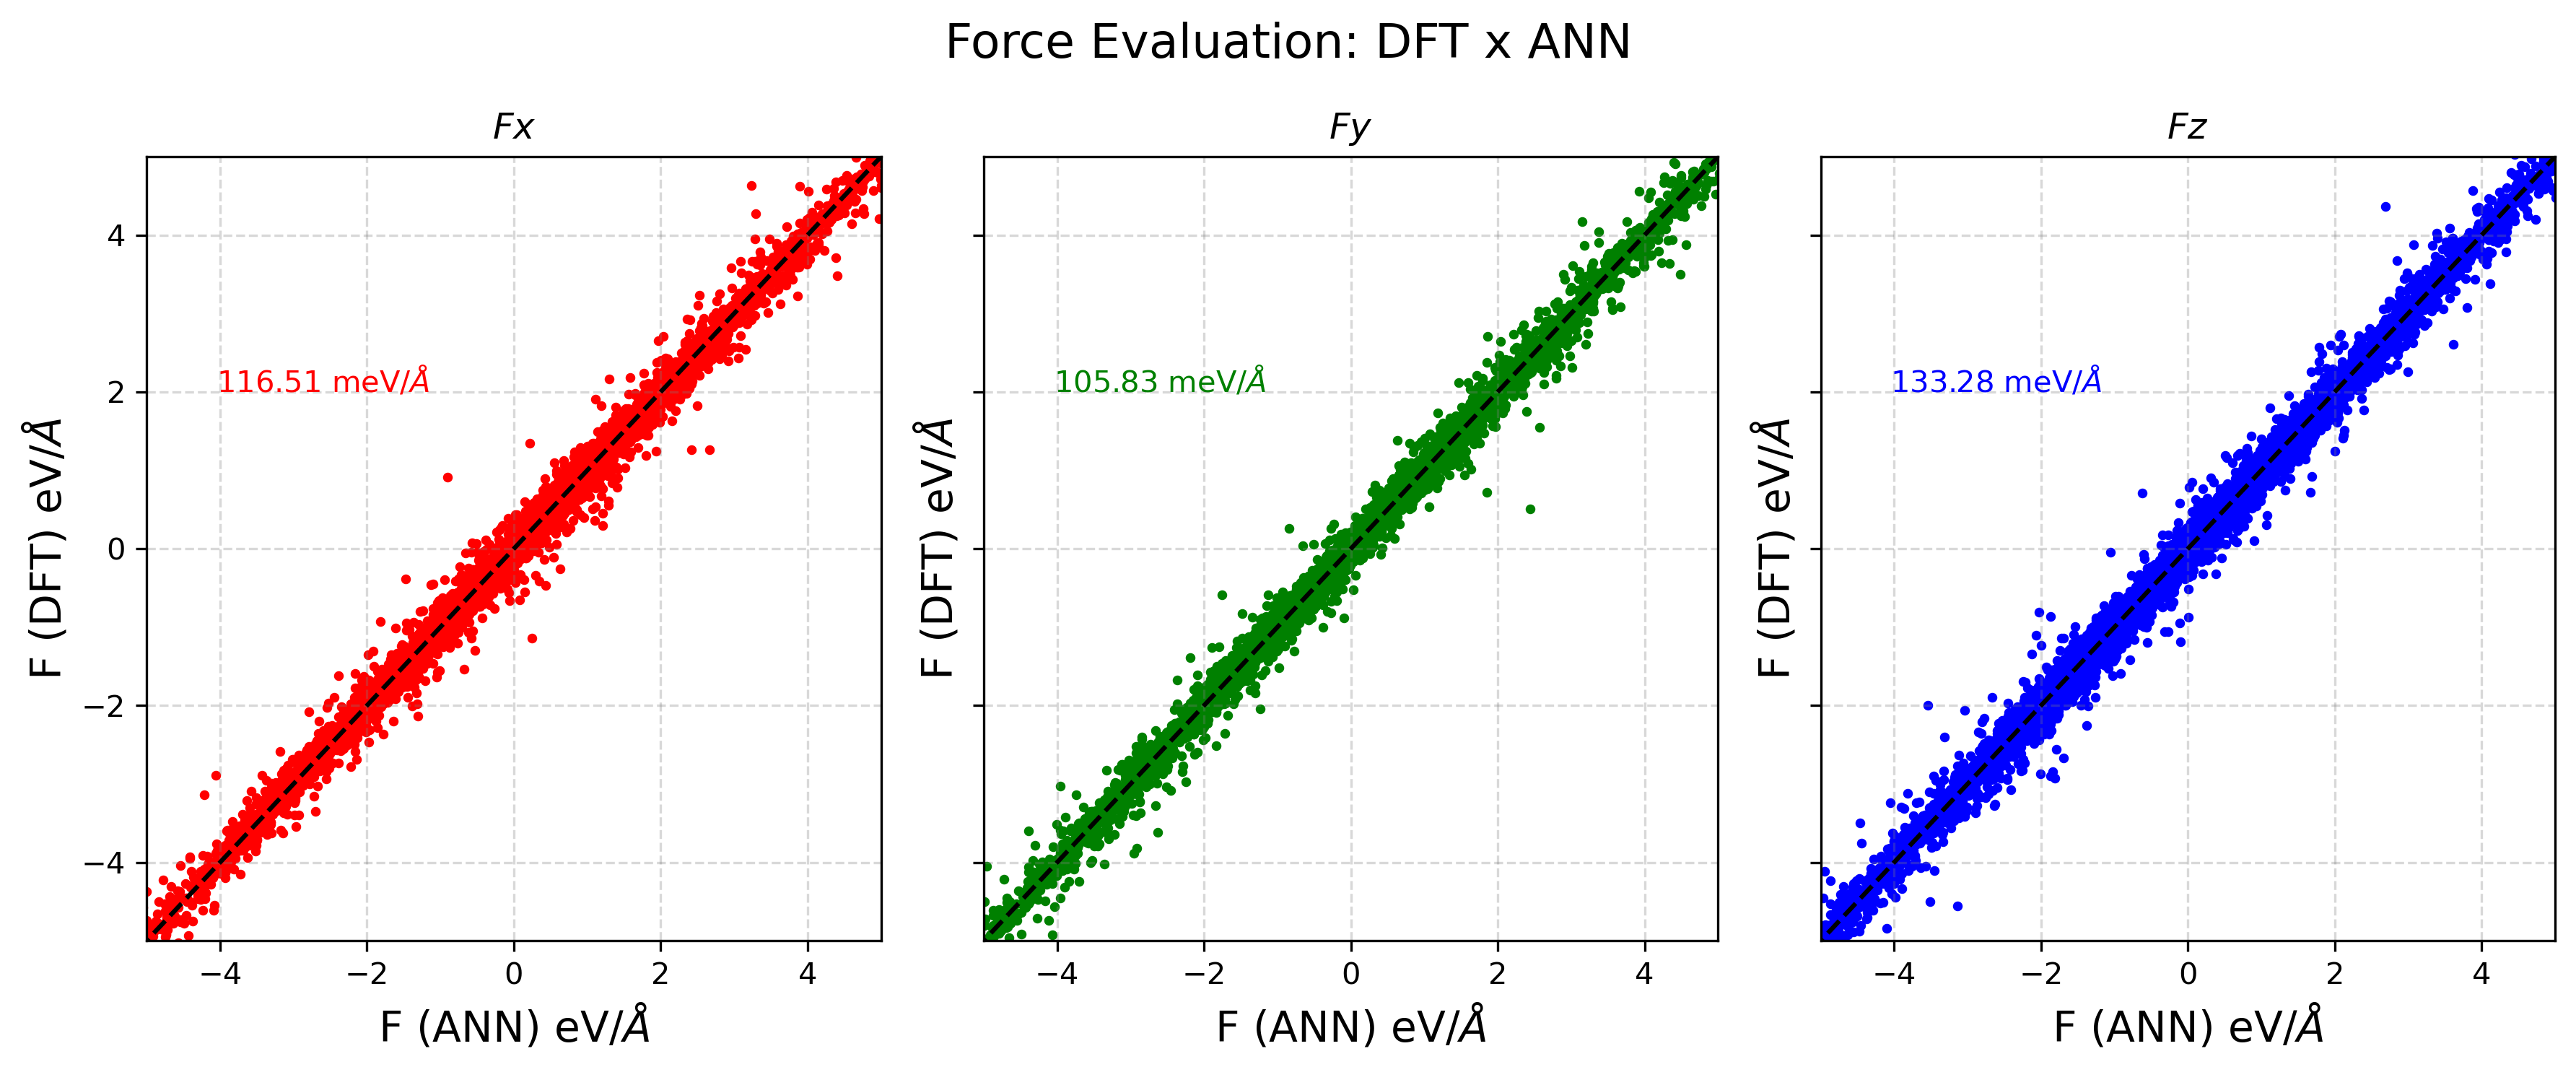

In [104]:
fig, axes = plt.subplots(ncols=3, figsize=(12,5),dpi=300, sharey=True, sharex=True)
fig.suptitle("Force Evaluation: DFT x ANN", fontsize=16)

coords = ['x', 'y', 'z']
colors = ['r', 'g', 'b']
RMSE = {'x': RMSE_Fx, 'y':RMSE_Fy, 'z':RMSE_Fz}
for ax, coord, color in zip(axes, coords, colors):
    # Min, Max Forces
    minF = min(df[f'F{coord}_ANN'].min(), df[f'F{coord}_DFT'].min())
    maxF = max(df[f'F{coord}_ANN'].max(), df[f'F{coord}_DFT'].max())
    lims_reta = [minF, maxF]
    # y = x
    ax.plot(lims_reta, lims_reta, color='k', ls='--')


    ax.set_title(f'$F{coord}$')
    ax.scatter(
        x = df[f'F{coord}_ANN'],
        y = df[f'F{coord}_DFT'],
        s=5,
        color=color
    )
    ax.grid(alpha=0.3, ls='--', color='gray')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel(r'F (ANN) eV/$\AA$', size=14)
    ax.set_ylabel(r'F (DFT) eV/$\AA$', size=14)

    # RMSE

    ax.text(x=-4.05, y=2, s=fr'{RMSE[coord]*1_000:.2f} meV/$\AA$', color=color)
    

plt.tight_layout()
plt.show()
